In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [25]:
# loading dataset
DATA_DIR = "../data/plantvillage dataset/color"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [8]:
# checking classes
class_names = train_ds.class_names

print("Classes:", len(class_names))
print(class_names[:10])

Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


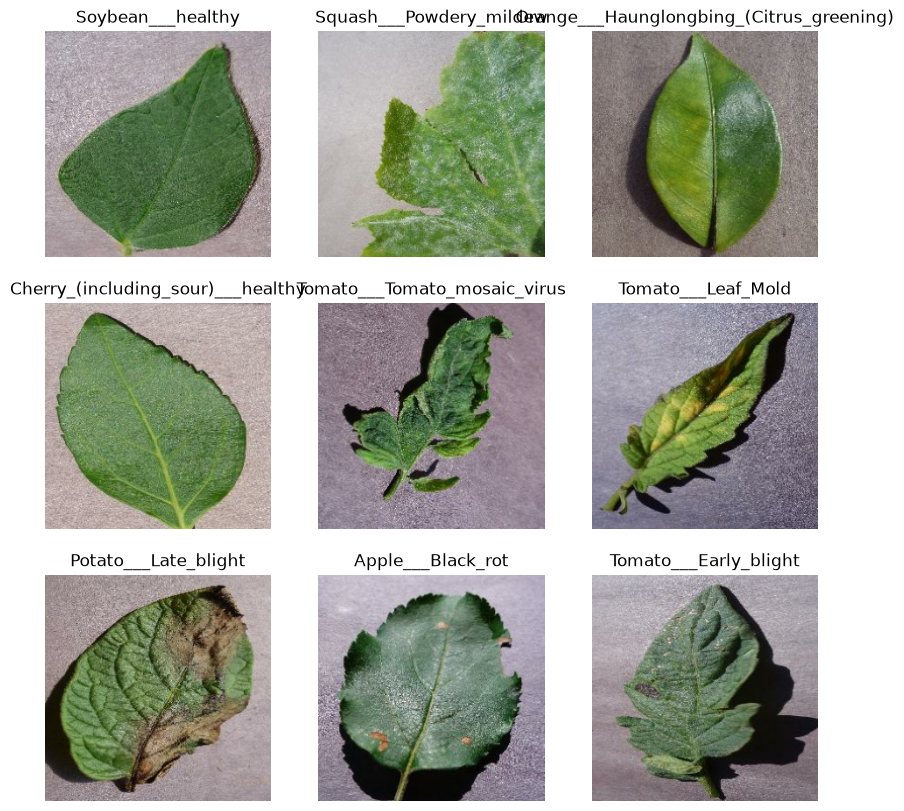

In [15]:
# visualize images
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [16]:
# Building CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224,224,3)),

    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),

    tf.keras.layers.Dense(len(class_names),activation='softmax')
])

c:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Training the model
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="../models/plant_disease_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint_callback]
)

Epoch 1/10


c:\Users\VICTUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 706s 518ms/step - accuracy: 0.7173 - loss: 0.9766 - val_accuracy: 0.8612 - val_loss: 0.4374
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 592s 436ms/step - accuracy: 0.8937 - loss: 0.3347 - val_accuracy: 0.8788 - val_loss: 0.3870
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 502s 370ms/step - accuracy: 0.9425 - loss: 0.1765 - val_accuracy: 0.8940 - val_loss: 0.3824
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 502s 370ms/step - accuracy: 0.9621 - loss: 0.1164 - val_accuracy: 0.9000 - val_loss: 0.3561
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 495s 364ms/step - accuracy: 0.9700 - loss: 0.0905 - val_accuracy: 0.8923 - val_loss: 0.4201
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 513s 377ms/step - accuracy: 0.9754 - loss: 0.0762 - val_accuracy: 0.9129 - val_loss: 0.3594
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1763s 1s/step - accuracy: 0.9794 - loss: 0.0648 - val_accuracy: 0.9153 - val_loss: 0.3477
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1775s 1s/step - accuracy: 0.9841 

In [30]:
# Testing prediction on a single image
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

best_model = load_model("../models/plant_disease_model.keras")

img_path = r"C:\Users\VICTUS\Desktop\Plant_Disease_Diagnosis\data\plantvillage dataset\color\Apple___Apple_scab\0a5e9323-dbad-432d-ac58-d291718345d9___FREC_Scab 3417.JPG"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
prediction = best_model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print(predicted_class)
print(np.max(prediction) * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
Apple___Apple_scab
99.996124


In [ ]:
# Testing prediction on multiple images
folder = "../data/plantvillage dataset/color/Peach___Bacterial_spot"

files = os.listdir(folder)[:10]

for file in files:
    img_path = os.path.join(folder, file)

    img = image.load_img(img_path, target_size=(224,224))

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = best_model.predict(img_array, verbose=0)

    pred = class_names[np.argmax(prediction)]

    print(file)
    print(pred)
    print("-" * 50)

00130039-8425-42e9-9dd9-15aead7271ff___Rut._Bact.S 3421.JPG
Peach___Bacterial_spot
--------------------------------------------------
002eddd0-b6b3-474c-be08-423e53e24f82___Rutg._Bact.S 1955.JPG
Peach___Bacterial_spot
--------------------------------------------------
00359c66-5d75-40ce-a5b7-6ef05959d2d2___Rut._Bact.S 1381.JPG
Peach___Bacterial_spot
--------------------------------------------------
004118fe-b351-4cad-83ca-280c77f82eaa___Rutg._Bact.S 1818.JPG
Peach___Bacterial_spot
--------------------------------------------------
005b14ab-17f0-40c3-af15-87abf7d4ac23___Rutg._Bact.S 2083.JPG
Peach___Bacterial_spot
--------------------------------------------------
0090cfcf-caf7-424d-b19c-533e09c6d24c___Rutg._Bact.S 2388.JPG
Peach___Bacterial_spot
--------------------------------------------------
00ddc106-692e-4c67-b2e8-569c924caf49___Rutg._Bact.S 1228.JPG
Peach___Bacterial_spot
--------------------------------------------------
00e6ad4a-5a62-48d7-ac68-9c0b8ec87f5f___Rut._Bact.S 1472.J

In [31]:
# Evaluating the best validation checkpoint
val_loss, val_accuracy = best_model.evaluate(val_ds)
print(f"Best checkpoint validation accuracy: {val_accuracy:.2%}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 43s 124ms/step - accuracy: 0.8700 - loss: 0.6270
Best checkpoint validation accuracy: 87.00%


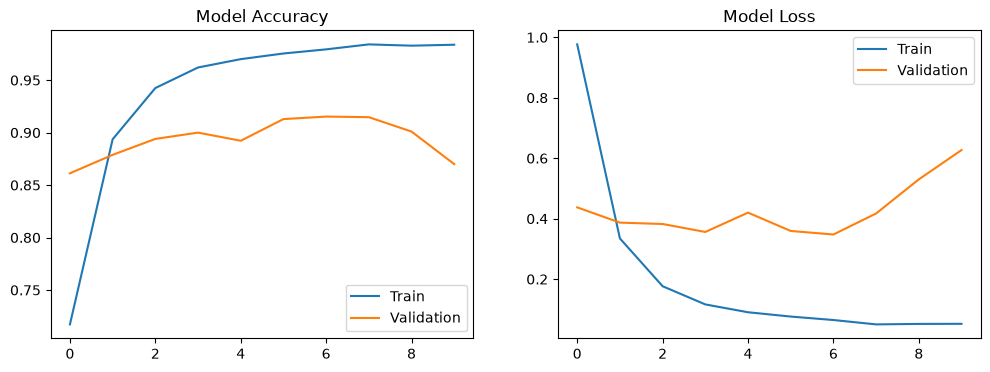

In [20]:
# training curves
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])

plt.show()

Accuracy : 0.8700
Precision: 0.8858
Recall   : 0.8700
F1 Score : 0.8704

Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.59      0.88      0.71       126
                                 Apple___Black_rot       0.75      0.95      0.84       132
                          Apple___Cedar_apple_rust       0.75      0.85      0.80        55
                                   Apple___healthy       0.85      0.84      0.84       329
                               Blueberry___healthy       0.95      0.88      0.92       295
          Cherry_(including_sour)___Powdery_mildew       0.83      0.91      0.87       232
                 Cherry_(including_sour)___healthy       0.89      0.89      0.89       167
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.87      0.51      0.64       108
                       Corn_(maize)___Common_rust_       0.98      0.99   

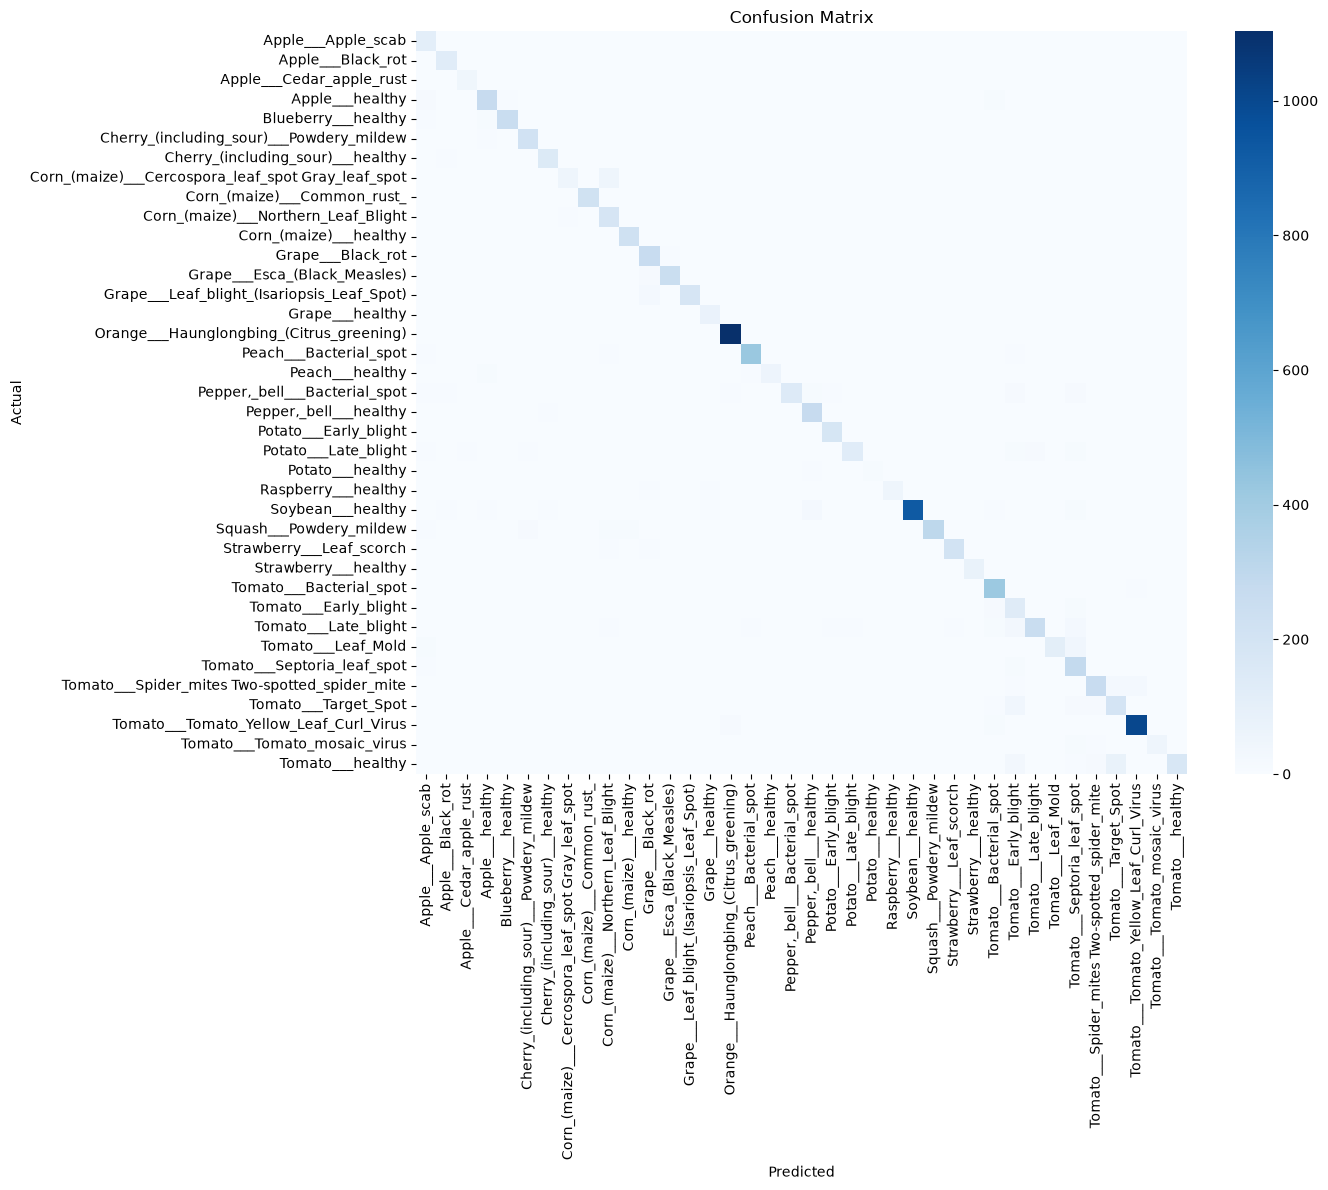

In [27]:
# model evaluation
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

# Collect true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Metrics
accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average='weighted'
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# Classification Report
print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [ ]:
# just reloading model to check if it works
from tensorflow.keras.models import load_model

model = load_model("../models/plant_disease_model.keras")